# Notebook 74 - Revised MATLAB, normal Kalman, and adaptive Kalman over time

This notebook reruns the complete Python sequence after the MATLAB adaptive-threshold and `houghpeaks` parity changes. The normal and adaptive Kalman outputs use identical Python detections and differ only in Kalman measurement covariance.

Primary variables are MATLAB `Fdat.Region.fas_length`/`FL` versus Python `FL_mm`, and MATLAB `Fdat.Region.fas_ang`/`ANG` versus Python `ANG_deg`.

In [1]:
from __future__ import annotations

import json
import math
import os
import subprocess
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
UTT_CANDIDATES = [
    ROOT / 'data' / 'matlab' / 'UTT_numeric_export.mat',
    Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat'),
]
UTT_EXPORT = next((path for path in UTT_CANDIDATES if path.exists()), None)
OUT = ROOT / 'results' / 'notebook74_revised_matlab_normal_adaptive_over_time'
RUN_ROOT = OUT / 'python_revised_exact_threshold_hough'
RUN_DIR = RUN_ROOT / VIDEO.stem
PY_NPZ = RUN_DIR / f'{VIDEO.stem}_strict_results.npz'
PY_META = RUN_DIR / f'{VIDEO.stem}_strict_metadata.json'
OUT.mkdir(parents=True, exist_ok=True)

for required in [VIDEO, MATLAB_RESULT, ROI_PATH]:
    assert required.exists(), required
assert UTT_EXPORT is not None

cap = cv2.VideoCapture(str(VIDEO))
fps = float(cap.get(cv2.CAP_PROP_FPS))
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()

print('Video:', VIDEO)
print('MATLAB:', MATLAB_RESULT)
print('UTT export:', UTT_EXPORT)
print('Video:', n_video_frames, 'frames,', fps, 'fps,', (frame_height, frame_width))
print('Output:', OUT)

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
MATLAB: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
UTT export: /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat
Video: 2667 frames, 33.341 fps, (562, 706)
Output: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook74_revised_matlab_normal_adaptive_over_time


## Fresh revised Python run

The new output directory prevents reuse of Notebook 70's pre-parity cached results. The adaptive run also computes the normal fixed-R reference from the exact same detections.

In [2]:
FORCE_RERUN = False

python_cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_ultratimtrack_adaptive_confidence.py'),
    str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--utt-export', str(UTT_EXPORT),
    '--results-dir', str(RUN_ROOT),
    '--seed-frames', '11',
    '--apo-maxangle', '10',
    '--candidate-persistence',
    '--apo-gating',
    '--kalman-mode', 'adaptive-anisotropic',
    '--compare-to-fixed-kalman',
    '--save-confidence-plots',
    '--no-annotated-video',
    '--save-overlays', '2',
    '--no-time-series-plot',
    '--progress-every', '250',
]

if FORCE_RERUN or not PY_NPZ.exists():
    print('Running:', ' '.join(python_cmd))
    env = dict(os.environ)
    env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
    started = time.time()
    completed = subprocess.run(python_cmd, cwd=ROOT, text=True, env=env)
    print(f'Elapsed: {time.time() - started:.1f} s')
    if completed.returncode != 0:
        raise RuntimeError(f'Python run failed with return code {completed.returncode}')
else:
    print('Using revised cached result:', PY_NPZ)

assert PY_NPZ.exists(), PY_NPZ
assert PY_META.exists(), PY_META

Running: /Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/run_ultratimtrack_adaptive_confidence.py /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 --roi-path /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json --utt-export /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat --results-dir /Users/grosbedou/PycharmProjects/NDORMS/results/notebook74_revised_matlab_normal_adaptive_over_time/python_revised_exact_threshold_hough --seed-frames 11 --apo-maxangle 10 --candidate-persistence --apo-gating --kalman-mode adaptive-anisotropic --compare-to-fixed-kalman --save-confidence-plots --no-annotated-video --save-overlays 2 --no-time-series-plot --progress-every 250


Loading ROIs: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json

Running TimTrack image stream...
TimTrack image geofeatures processed 250
TimTrack image geofeatures processed 500
TimTrack image geofeatures processed 750
TimTrack image geofeatures processed 1000
TimTrack image geofeatures processed 1250
TimTrack image geofeatures processed 1500
TimTrack image geofeatures processed 1750
TimTrack image geofeatures processed 2000
TimTrack image geofeatures processed 2250
TimTrack image geofeatures processed 2500

Selecting autonomous fascicle seed...
Selected seed alpha: 17.600 deg (a17.50_x350_l75)

Estimating fascicle KLT affines...
one-step KLT processed 251/2667
one-step KLT processed 501/2667
one-step KLT processed 751/2667
one-step KLT processed 1001/2667
one-step KLT processed 1251/2667
one-step KLT processed 1501/2667
one-step KLT processed 1751/2667
one-step KLT processed 2001/2667
one-step KLT processed 2251/2667
one-step KLT processed 2501/2667
one-

## Match variables and frames

In [3]:
mat = loadmat(MATLAB_RESULT, simplify_cells=True)
region = mat['Fdat']['Region']
matlab = pd.DataFrame({
    'time_s': np.asarray(region['Time'], dtype=float).reshape(-1),
    'matlab_FL_mm': np.asarray(region['fas_length'], dtype=float).reshape(-1),
    'matlab_ANG_deg': np.asarray(region['fas_ang'], dtype=float).reshape(-1),
})

with np.load(PY_NPZ, allow_pickle=True) as loaded:
    py = {key: loaded[key] for key in loaded.files}

required = ['frame', 'time_s', 'fixed_FL_mm', 'fixed_ANG_deg', 'FL_mm', 'ANG_deg']
missing = [key for key in required if key not in py]
if missing:
    raise KeyError(missing)

py_time = np.asarray(py['time_s'], dtype=float).reshape(-1)
mat_time = matlab['time_s'].to_numpy(dtype=float)
offset_rows = []
for offset in range(5):
    n = min(len(mat_time), len(py_time) - offset)
    if n > 10:
        score = float(np.nanmedian(np.abs(py_time[offset:offset + min(n, 250)] - mat_time[:min(n, 250)])))
        offset_rows.append({'python_offset': offset, 'median_abs_time_error_s': score, 'n': n})
offset_table = pd.DataFrame(offset_rows)
python_offset = int(offset_table.sort_values('median_abs_time_error_s').iloc[0]['python_offset'])
n = min(len(matlab), len(py_time) - python_offset)
sl = slice(python_offset, python_offset + n)

aligned = pd.DataFrame({
    'time_s': mat_time[:n],
    'python_time_s': py_time[sl],
    'python_frame': np.asarray(py['frame'], dtype=int).reshape(-1)[sl],
    'matlab_FL_mm': matlab['matlab_FL_mm'].to_numpy(dtype=float)[:n],
    'python_normal_FL_mm': np.asarray(py['fixed_FL_mm'], dtype=float).reshape(-1)[sl],
    'python_adaptive_FL_mm': np.asarray(py['FL_mm'], dtype=float).reshape(-1)[sl],
    'matlab_ANG_deg': matlab['matlab_ANG_deg'].to_numpy(dtype=float)[:n],
    'python_normal_ANG_deg': np.asarray(py['fixed_ANG_deg'], dtype=float).reshape(-1)[sl],
    'python_adaptive_ANG_deg': np.asarray(py['ANG_deg'], dtype=float).reshape(-1)[sl],
})
aligned.to_csv(OUT / 'aligned_matlab_python_normal_adaptive_revised.csv', index=False)
print(offset_table)
print('Selected Python offset:', python_offset, '| matched rows:', n)
aligned.head()

   python_offset  median_abs_time_error_s     n
0              0                 0.029992  2666
1              1                 0.000001  2666
2              2                 0.029994  2665
3              3                 0.059987  2664
4              4                 0.089981  2663
Selected Python offset: 1 | matched rows: 2666


,time_s,python_time_s,python_frame,matlab_FL_mm,python_normal_FL_mm,python_adaptive_FL_mm,matlab_ANG_deg,python_normal_ANG_deg,python_adaptive_ANG_deg
0,0.029993,0.029993,1,72.307050,75.449997,75.449997,18.520489,17.599422,17.599422
1,0.059986,0.059986,2,72.304143,75.449773,75.449773,18.520433,17.598772,17.598772
2,0.089979,0.089979,3,72.303613,75.458061,75.458062,18.519920,17.594911,17.594911
3,0.119972,0.119972,4,72.306344,75.468903,75.468904,18.517583,17.590912,17.590912
4,0.149965,0.149966,5,72.312694,75.483793,75.483765,18.514817,17.585576,17.585583


## Agreement and before-versus-after comparison

In [4]:
def lins_ccc(reference, estimate):
    ref = np.asarray(reference, dtype=float)
    est = np.asarray(estimate, dtype=float)
    keep = np.isfinite(ref) & np.isfinite(est)
    ref, est = ref[keep], est[keep]
    var_ref = np.var(ref, ddof=1)
    var_est = np.var(est, ddof=1)
    covariance = np.cov(ref, est, ddof=1)[0, 1]
    denominator = var_ref + var_est + (np.mean(ref) - np.mean(est)) ** 2
    return float(2 * covariance / denominator) if denominator > 0 else np.nan

def agreement(method, variable, unit):
    ref = aligned[f'matlab_{variable}'].to_numpy(dtype=float)
    est = aligned[f'python_{method}_{variable}'].to_numpy(dtype=float)
    keep = np.isfinite(ref) & np.isfinite(est)
    ref, est = ref[keep], est[keep]
    diff = est - ref
    return {
        'run': 'revised', 'method': method, 'variable': variable, 'unit': unit, 'n': len(diff),
        'matlab_mean': np.mean(ref), 'python_mean': np.mean(est),
        'bias_python_minus_matlab': np.mean(diff),
        'mae': np.mean(np.abs(diff)), 'rmse': np.sqrt(np.mean(diff ** 2)),
        'max_abs_diff': np.max(np.abs(diff)),
        'pearson_r': np.corrcoef(ref, est)[0, 1], 'lins_ccc': lins_ccc(ref, est),
    }

revised_stats = pd.DataFrame([
    agreement('normal', 'FL_mm', 'mm'),
    agreement('normal', 'ANG_deg', 'deg'),
    agreement('adaptive', 'FL_mm', 'mm'),
    agreement('adaptive', 'ANG_deg', 'deg'),
])
revised_stats.to_csv(OUT / 'revised_agreement_statistics.csv', index=False)

old_path = ROOT / 'results' / 'notebook70_matlab_normal_adaptive_kalman_comparison' / 'matlab_python_normal_adaptive_equivalence_statistics.csv'
if old_path.exists():
    old = pd.read_csv(old_path)
    old = old[old['variable'].isin(['FL_mm', 'ANG_deg'])].copy()
    old['run'] = 'before parity fixes'
    comparable = pd.concat([old[revised_stats.columns.intersection(old.columns)], revised_stats], ignore_index=True)
    before = old[['method', 'variable', 'mae', 'rmse', 'lins_ccc']].rename(columns={
        'mae': 'before_mae', 'rmse': 'before_rmse', 'lins_ccc': 'before_lins_ccc'
    })
    after = revised_stats[['method', 'variable', 'mae', 'rmse', 'lins_ccc']].rename(columns={
        'mae': 'after_mae', 'rmse': 'after_rmse', 'lins_ccc': 'after_lins_ccc'
    })
    before_after = before.merge(after, on=['method', 'variable'])
    before_after['rmse_change_after_minus_before'] = before_after['after_rmse'] - before_after['before_rmse']
    before_after['mae_change_after_minus_before'] = before_after['after_mae'] - before_after['before_mae']
    before_after.to_csv(OUT / 'before_after_parity_fix_comparison.csv', index=False)
    display(before_after)
display(revised_stats)

,method,variable,before_mae,before_rmse,before_lins_ccc,after_mae,after_rmse,after_lins_ccc,rmse_change_after_minus_before,mae_change_after_minus_before
0,normal,FL_mm,2.412748,2.867034,0.954566,2.112008,2.549416,0.963830,-0.317618,-0.300740
1,normal,ANG_deg,1.321171,1.599246,0.946790,1.138250,1.393651,0.958657,-0.205595,-0.182921
2,adaptive,FL_mm,2.416541,2.885628,0.953914,2.135859,2.593571,0.962479,-0.292057,-0.280682
3,adaptive,ANG_deg,1.326267,1.600611,0.946687,1.153223,1.406780,0.957860,-0.193831,-0.173044


,run,method,variable,unit,n,matlab_mean,python_mean,bias_python_minus_matlab,mae,rmse,max_abs_diff,pearson_r,lins_ccc
0,revised,normal,FL_mm,mm,2666,55.215216,53.440446,-1.774770,2.112008,2.549416,5.827917,0.981023,0.963830
1,revised,normal,ANG_deg,deg,2666,25.526129,26.532409,1.006280,1.138250,1.393651,4.276031,0.983148,0.958657
2,revised,adaptive,FL_mm,mm,2666,55.215216,53.341437,-1.873780,2.135859,2.593571,6.037671,0.981713,0.962479
3,revised,adaptive,ANG_deg,deg,2666,25.526129,26.581804,1.055675,1.153223,1.406780,4.251895,0.984328,0.957860


## Fascicle length over time

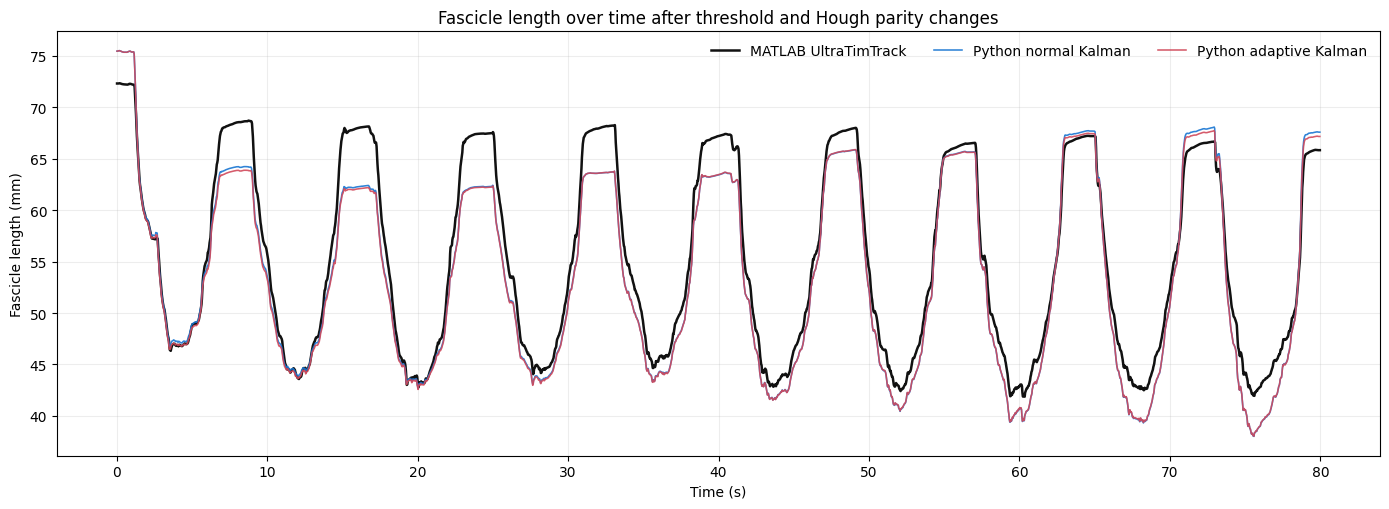

In [5]:
COLORS = {'matlab': '#111111', 'normal': '#1976d2', 'adaptive': '#d1495b'}

fig, ax = plt.subplots(figsize=(14, 5.2))
ax.plot(aligned['time_s'], aligned['matlab_FL_mm'], color=COLORS['matlab'], linewidth=1.8, label='MATLAB UltraTimTrack')
ax.plot(aligned['time_s'], aligned['python_normal_FL_mm'], color=COLORS['normal'], linewidth=1.15, alpha=0.9, label='Python normal Kalman')
ax.plot(aligned['time_s'], aligned['python_adaptive_FL_mm'], color=COLORS['adaptive'], linewidth=1.15, alpha=0.9, label='Python adaptive Kalman')
ax.set(title='Fascicle length over time after threshold and Hough parity changes', xlabel='Time (s)', ylabel='Fascicle length (mm)')
ax.grid(alpha=0.22)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()
length_plot = OUT / 'fascicle_length_matlab_python_normal_adaptive_revised.png'
fig.savefig(length_plot, dpi=180, bbox_inches='tight')
plt.show()

## Fascicle angle over time

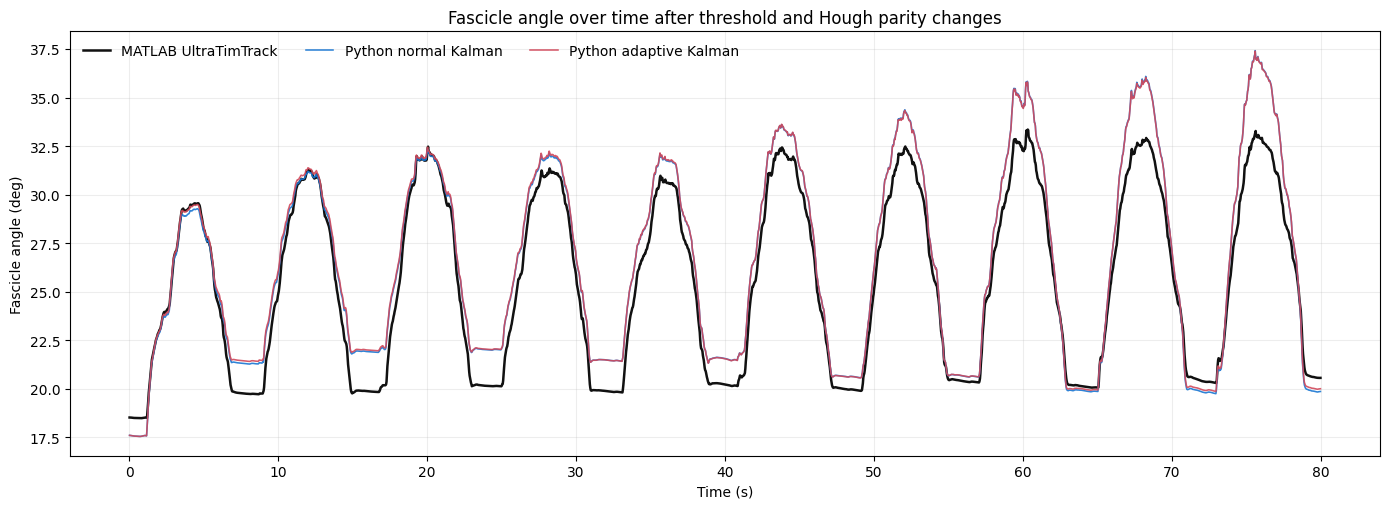

In [6]:
fig, ax = plt.subplots(figsize=(14, 5.2))
ax.plot(aligned['time_s'], aligned['matlab_ANG_deg'], color=COLORS['matlab'], linewidth=1.8, label='MATLAB UltraTimTrack')
ax.plot(aligned['time_s'], aligned['python_normal_ANG_deg'], color=COLORS['normal'], linewidth=1.15, alpha=0.9, label='Python normal Kalman')
ax.plot(aligned['time_s'], aligned['python_adaptive_ANG_deg'], color=COLORS['adaptive'], linewidth=1.15, alpha=0.9, label='Python adaptive Kalman')
ax.set(title='Fascicle angle over time after threshold and Hough parity changes', xlabel='Time (s)', ylabel='Fascicle angle (deg)')
ax.grid(alpha=0.22)
ax.legend(ncol=3, frameon=False)
fig.tight_layout()
angle_plot = OUT / 'fascicle_angle_matlab_python_normal_adaptive_revised.png'
fig.savefig(angle_plot, dpi=180, bbox_inches='tight')
plt.show()

## Interpretation of the `71` value

`TrackingData.BlockSize = [21, 71]` is the MATLAB `vision.PointTracker` KLT block size (width by height), not an ROI. The user-selected ROIs are the superficial, deep, and fascicle rectangles in `UltraTimTrack_test_rois.json`.

An older Python threshold approximation also used a `71x71` neighborhood. That threshold neighborhood affected binary masks, especially aponeurosis masks, but it was not the sole source of final drift. The parity ladder showed the first discrepancy in TimTrack image measurements and a larger additional discrepancy in the independently implemented KLT fascicle prior. The revised run tests how much the threshold/Hough fixes alone recover.

In [7]:
metadata = json.loads(PY_META.read_text())
summary_lines = [
    '# Notebook 74 revised three-way comparison',
    '',
    f'Matched frames: {len(aligned)}; Python offset: {python_offset}; runtime: {metadata.get("runtime_s", np.nan):.1f} s.',
    '',
    '## Revised agreement',
]
for _, row in revised_stats.iterrows():
    summary_lines.append(
        f"- {row['method']} {row['variable']}: bias {row['bias_python_minus_matlab']:.3f} {row['unit']}, "
        f"MAE {row['mae']:.3f}, RMSE {row['rmse']:.3f}, CCC {row['lins_ccc']:.3f}."
    )
if 'before_after' in globals():
    summary_lines += ['', '## Change from Notebook 70']
    for _, row in before_after.iterrows():
        direction = 'closer' if row['rmse_change_after_minus_before'] < 0 else 'farther'
        summary_lines.append(
            f"- {row['method']} {row['variable']}: RMSE {row['before_rmse']:.3f} -> {row['after_rmse']:.3f} "
            f"({direction} by {abs(row['rmse_change_after_minus_before']):.3f})."
        )
summary_lines += [
    '',
    '## `71` clarification',
    '- MATLAB BlockSize `[21, 71]` is the KLT point-tracker window, not the ROI.',
    '- The old `71x71` threshold approximation affected masks but was not the only source of drift.',
    '- The parity ladder also identified independent KLT prior drift after the image-measurement stage.',
]
summary_text = '\n'.join(summary_lines)
(OUT / 'notebook74_summary.md').write_text(summary_text)
print(summary_text)
print('\nLength plot:', length_plot)
print('Angle plot:', angle_plot)

# Notebook 74 revised three-way comparison

Matched frames: 2666; Python offset: 1; runtime: 769.0 s.

## Revised agreement
- normal FL_mm: bias -1.775 mm, MAE 2.112, RMSE 2.549, CCC 0.964.
- normal ANG_deg: bias 1.006 deg, MAE 1.138, RMSE 1.394, CCC 0.959.
- adaptive FL_mm: bias -1.874 mm, MAE 2.136, RMSE 2.594, CCC 0.962.
- adaptive ANG_deg: bias 1.056 deg, MAE 1.153, RMSE 1.407, CCC 0.958.

## Change from Notebook 70
- normal FL_mm: RMSE 2.867 -> 2.549 (closer by 0.318).
- normal ANG_deg: RMSE 1.599 -> 1.394 (closer by 0.206).
- adaptive FL_mm: RMSE 2.886 -> 2.594 (closer by 0.292).
- adaptive ANG_deg: RMSE 1.601 -> 1.407 (closer by 0.194).

## `71` clarification
- MATLAB BlockSize `[21, 71]` is the KLT point-tracker window, not the ROI.
- The old `71x71` threshold approximation affected masks but was not the only source of drift.
- The parity ladder also identified independent KLT prior drift after the image-measurement stage.

Length plot: /Users/grosbedou/PycharmProjects/NDORMS/r